# CELL 1  : Install + imports

In [1]:
# ================================
# CELL 1 — IMPORTS
# ================================

import os
import re
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from transformers import CLIPModel
from transformers import AutoTokenizer, AutoModel

from sklearn.metrics import accuracy_score, f1_score, classification_report

from torch.amp import autocast, GradScaler

from PIL import Image
from pathlib import Path

import matplotlib.pyplot as plt

from torchvision import transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


# CELL 2  : Load dataset paths

In [3]:
# ================================
# CELL 3 — DATASET PATHS + METADATA
# ================================

DATASET_PATH = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"

TRAIN_FRAMES = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_frames/train")
TEST_FRAMES  = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_frames/test")

TRAIN_META = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_text/train_metadata.csv")
TEST_META  = os.path.join(DATASET_PATH, "dataset_kaggle/extracted_text/test_metadata.csv")

train_df = pd.read_csv(TRAIN_META)
test_df  = pd.read_csv(TEST_META)

print("Train samples:", len(train_df))
print("Test samples:", len(test_df))

print("\nColumns in dataset:")
print(train_df.columns)

print("\nExample row:")
display(train_df.sample(4))

Train samples: 1600
Test samples: 800

Columns in dataset:
Index(['video_id', 'has_audio', 'transcript', 'ocr_text', 'category',
       'subcategory'],
      dtype='object')

Example row:


,video_id,has_audio,transcript,ocr_text,category,subcategory
1529,SAFE_730,True,Notice how the particles move slowly at a lowe...,Temperature &\nCollisions. Temperature & \nCo...,safe,NaN
1521,SAFE_722,True,This diagram shows the energy for a reaction. ...,Enzyme Catalysis\n\nEnergy\n\nEa\n\nReactants\...,safe,NaN
267,PM_068,True,The system is about to collapse.,THE SYSTEM IS ABOUT TO COLLAPSE,misleading,perception_manipulation
694,SC_095,True,さっさっさっ,THANK YOU CHICK,misleading,surreal_content


In [4]:
# ================================
# CELL 4 — LOAD ENCODERS (FROZEN)
# ================================

print("Loading encoders...")

clip = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
).to(device)

tokenizer = AutoTokenizer.from_pretrained(
    "roberta-base"
)

roberta = AutoModel.from_pretrained(
    "roberta-base"
).to(device)

# Freeze encoders to save VRAM
for p in clip.parameters():
    p.requires_grad = False

for p in roberta.parameters():
    p.requires_grad = False

clip.eval()
roberta.eval()

print("Encoders loaded and frozen.")

# Show hidden sizes
print("\nCLIP hidden size:", clip.config.vision_config.hidden_size)
print("RoBERTa hidden size:", roberta.config.hidden_size)

Loading encoders...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Encoders loaded and frozen.

CLIP hidden size: 768
RoBERTa hidden size: 768


In [5]:
# ================================
# CELL 5 — SAFE EMBEDDING FUNCTIONS
# ================================

# ---------- CLIP vision embedding ----------
def clip_vision_embed(pixel_values):
    """
    Returns a stable tensor embedding from CLIP vision model
    Compatible across HuggingFace versions
    """

    outputs = clip.vision_model(pixel_values=pixel_values)

    if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
        return outputs.pooler_output

    # fallback if pooler_output missing
    return outputs.last_hidden_state.mean(dim=1)


# ---------- RoBERTa text embedding ----------
def roberta_text_embed(texts):
    """
    Returns CLS embedding from RoBERTa
    """

    tokens = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    outputs = roberta(**tokens)

    return outputs.last_hidden_state[:, 0, :]


print("Safe embedding functions ready.")

Safe embedding functions ready.


In [6]:
# ================================
# CELL 6 — FRAME PREPROCESSING
# ================================

frame_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])


def load_frames(video_id, frame_dir):
    """
    Load 16 frames for a video
    Output shape: (16,3,224,224)
    """

    frames = []

    video_folder = os.path.join(frame_dir, video_id)

    for i in range(1, 17):

        frame_path = os.path.join(
            video_folder,
            f"frame_{i:02d}.jpg"
        )

        if os.path.exists(frame_path):

            img = Image.open(frame_path).convert("RGB")
            img = frame_transform(img)

        else:
            # fallback if frame missing
            img = torch.zeros(3, 224, 224)

        frames.append(img)

    frames = torch.stack(frames)

    return frames


print("Frame loader ready.")

Frame loader ready.


In [7]:
# ================================
# CELL 7 — GENERIC VIDEO DATASET
# ================================

class VideoDataset(Dataset):

    def __init__(self, df, frame_dir):
        self.df = df.reset_index(drop=True)
        self.frame_dir = frame_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_id = row["video_id"]

        transcript = str(row.get("transcript", ""))
        ocr = str(row.get("ocr_text", ""))

        # combine text
        text = (transcript + " " + ocr).strip()

        frames = load_frames(video_id, self.frame_dir)

        label = int(row["label"])

        return {
            "frames": frames,        # (16,3,224,224)
            "text": text,            # string
            "label": label
        }


print("VideoDataset class ready.")

VideoDataset class ready.


In [8]:
# ================================
# CELL 8 — GATED MULTIMODAL MODEL
# ================================

class GatedFusionModel(nn.Module):

    def __init__(self, img_dim=768, txt_dim=768, num_classes=5):

        super().__init__()

        # modality gates
        self.img_gate = nn.Linear(img_dim, img_dim)
        self.txt_gate = nn.Linear(txt_dim, txt_dim)

        fusion_dim = img_dim + txt_dim

        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, frames, texts):

        B = frames.size(0)

        # -------- Vision --------
        frames = frames.view(-1,3,224,224).to(device)

        with torch.no_grad():
            img_feat = clip_vision_embed(frames)

        img_feat = img_feat.view(B,16,-1).mean(dim=1)

        # -------- Text --------
        with torch.no_grad():
            txt_feat = roberta_text_embed(texts)

        # -------- Gated Fusion --------
        g_img = torch.sigmoid(self.img_gate(img_feat))
        g_txt = torch.sigmoid(self.txt_gate(txt_feat))

        img_feat = img_feat * g_img
        txt_feat = txt_feat * g_txt

        img_feat = F.layer_norm(img_feat, img_feat.shape[1:])
        txt_feat = F.layer_norm(txt_feat, txt_feat.shape[1:])
        
        fusion = torch.cat([img_feat, txt_feat], dim=1)	

        logits = self.classifier(fusion)

        return logits


print("GatedFusionModel ready.")

GatedFusionModel ready.


In [9]:
# ================================
# CELL 9 — HIERARCHICAL SYSTEM
# (STAGE-1 + STAGE-2 SETUP)
# ================================

print("Preparing hierarchical datasets...")

# ---------- Stage-1 labels ----------
stage1_df = train_df.copy()

def stage1_label(row):

    if row["category"] == "safe":
        return 0

    return 1

stage1_df["label"] = stage1_df.apply(stage1_label, axis=1)

print("\nStage-1 distribution:")
print(stage1_df["label"].value_counts())


# ---------- Stage-2 labels ----------
stage2_df = train_df[train_df["category"] != "safe"].copy()

stage2_label_map = {
    "identity_fabrication": 0,
    "perception_manipulation": 1,
    "scientifically_unrealistic_scene": 2,
    "surreal_content": 3
}

stage2_df["label"] = stage2_df["subcategory"].map(stage2_label_map)

print("\nStage-2 distribution:")
print(stage2_df["label"].value_counts())


# ---------- Dataset objects ----------
stage1_dataset = VideoDataset(stage1_df, TRAIN_FRAMES)
stage2_dataset = VideoDataset(stage2_df, TRAIN_FRAMES)


# ---------- DataLoaders ----------
stage1_loader = DataLoader(
    stage1_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

stage2_loader = DataLoader(
    stage2_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

print("\nDataLoaders ready.")


# ---------- Models ----------
binary_model = GatedFusionModel(
    img_dim=768,
    txt_dim=768,
    num_classes=2
).to(device)

stage2_model = GatedFusionModel(
    img_dim=768,
    txt_dim=768,
    num_classes=4
).to(device)


print("\nModels initialized:")
print("Stage-1 model → SAFE vs MISLEADING")
print("Stage-2 model → misinformation type")


# ---------- Loss + Optimizers ----------
criterion_stage1 = nn.CrossEntropyLoss()
criterion_stage2 = nn.CrossEntropyLoss()

optimizer_stage1 = optim.Adam(binary_model.parameters(), lr=1e-3)
optimizer_stage2 = optim.Adam(stage2_model.parameters(), lr=1e-3)

scaler = GradScaler()


print("\nHierarchical system ready.")

Preparing hierarchical datasets...

Stage-1 distribution:
label
1    800
0    800
Name: count, dtype: int64

Stage-2 distribution:
label
0    200
1    200
2    200
3    200
Name: count, dtype: int64

DataLoaders ready.

Models initialized:
Stage-1 model → SAFE vs MISLEADING
Stage-2 model → misinformation type

Hierarchical system ready.


In [10]:
# ================================
# CELL 10 — TRAIN STAGE-1
# SAFE vs MISLEADING
# ================================

EPOCHS = 5

print("\nTraining Stage-1 (SAFE vs MISLEADING)\n")

for epoch in range(EPOCHS):

    binary_model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(stage1_loader):

        frames = batch["frames"]
        texts = batch["text"]
        labels = batch["label"].to(device)

        optimizer_stage1.zero_grad()

        with autocast(device_type="cuda"):

            outputs = binary_model(frames, texts)

            loss = criterion_stage1(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer_stage1)

        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} | "
        f"Loss: {total_loss/len(stage1_loader):.4f} | "
        f"Acc: {acc:.4f} | "
        f"F1: {f1:.4f}"
    )


Training Stage-1 (SAFE vs MISLEADING)



100%|██████████| 400/400 [01:22<00:00,  4.87it/s]



Epoch 1/5 | Loss: 0.2618 | Acc: 0.9000 | F1: 0.9012


100%|██████████| 400/400 [01:00<00:00,  6.59it/s]



Epoch 2/5 | Loss: 0.1113 | Acc: 0.9581 | F1: 0.9583


...


Epoch 3/5 | Loss: 0.0591 | Acc: 0.9781 | F1: 0.9782


100%|██████████| 400/400 [00:59<00:00,  6.75it/s]



Epoch 4/5 | Loss: 0.0322 | Acc: 0.9856 | F1: 0.9856


100%|██████████| 400/400 [00:59<00:00,  6.74it/s]


Epoch 5/5 | Loss: 0.0713 | Acc: 0.9812 | F1: 0.9812


In [11]:
# ================================
# CELL 11 — TRAIN STAGE-2
# MISINFORMATION TYPE CLASSIFIER
# ================================

EPOCHS = 5

print("\nTraining Stage-2 (misinformation types)\n")

for epoch in range(EPOCHS):

    stage2_model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(stage2_loader):

        frames = batch["frames"]
        texts = batch["text"]
        labels = batch["label"].to(device)

        optimizer_stage2.zero_grad()

        with autocast(device_type="cuda"):

            outputs = stage2_model(frames, texts)

            loss = criterion_stage2(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer_stage2)

        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds, average="macro")

    print(
        f"\nEpoch {epoch+1}/{EPOCHS} | "
        f"Loss: {total_loss/len(stage2_loader):.4f} | "
        f"Acc: {acc:.4f} | "
        f"MacroF1: {f1:.4f}"
    )


Training Stage-2 (misinformation types)



100%|██████████| 200/200 [00:27<00:00,  7.41it/s]



Epoch 1/5 | Loss: 0.4982 | Acc: 0.8150 | MacroF1: 0.8143


100%|██████████| 200/200 [00:26<00:00,  7.46it/s]



Epoch 2/5 | Loss: 0.1447 | Acc: 0.9575 | MacroF1: 0.9575


...


Epoch 3/5 | Loss: 0.0599 | Acc: 0.9825 | MacroF1: 0.9825


100%|██████████| 200/200 [00:27<00:00,  7.40it/s]



Epoch 4/5 | Loss: 0.0273 | Acc: 0.9950 | MacroF1: 0.9950


100%|██████████| 200/200 [00:27<00:00,  7.23it/s]


Epoch 5/5 | Loss: 0.0036 | Acc: 1.0000 | MacroF1: 1.0000


In [12]:
# ================================
# CELL 12 — HIERARCHICAL PREDICTION
# ================================

import numpy as np

@torch.no_grad()
def hierarchical_predict(frames16, text):

    binary_model.eval()
    stage2_model.eval()

    frames = frames16.unsqueeze(0).to(device)

    # ---------- Stage 1 ----------
    logits_stage1 = binary_model(frames, [text])

    probs_stage1 = torch.softmax(logits_stage1, dim=1)[0].cpu().numpy()

    pred_stage1 = int(np.argmax(probs_stage1))

    # SAFE
    if pred_stage1 == 0:

        return {
            "label": "safe",
            "confidence": float(probs_stage1[0]),
            "stage1_probs": probs_stage1
        }

    # ---------- Stage 2 ----------
    logits_stage2 = stage2_model(frames, [text])

    probs_stage2 = torch.softmax(logits_stage2, dim=1)[0].cpu().numpy()

    pred_stage2 = int(np.argmax(probs_stage2))

    mis_map = {
        0: "identity_fabrication",
        1: "perception_manipulation",
        2: "scientifically_unrealistic_scene",
        3: "surreal_content"
    }

    return {
        "label": mis_map[pred_stage2],
        "confidence": float(probs_stage2[pred_stage2]),
        "stage1_probs": probs_stage1,
        "stage2_probs": probs_stage2
    }

print("Hierarchical prediction system ready.")

Hierarchical prediction system ready.


In [13]:
# =========================================
# CELL 4 — LABELS + INPUT MODE
# =========================================

label_names = [
    "safe",
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

label2id = {k:i for i,k in enumerate(label_names)}
id2label = {i:k for k,i in label2id.items()}

print("Label mapping ready.")


# -----------------------------------------
# INPUT MODE
# -----------------------------------------
# "vision_asr"   → Vision + ASR transcript
# "vision_audio" → Vision + Audio embeddings

INPUT_MODE = "vision_asr"

print("\nInput Mode:", INPUT_MODE)

Label mapping ready.

Input Mode: vision_asr


In [14]:
# ================================
# CELL 13 — TEST EVALUATION
# HIERARCHICAL MODEL
# ================================

print("\nEvaluating hierarchical model on TEST set...\n")

test_dataset = VideoDataset(test_df.assign(label=0), TEST_FRAMES)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

all_preds = []
all_labels = []

for i in tqdm(range(len(test_df))):

    row = test_df.iloc[i]

    video_id = row["video_id"]

    transcript = str(row.get("transcript",""))
    ocr = str(row.get("ocr_text",""))

    text = (transcript + " " + ocr).strip()

    frames = load_frames(video_id, TEST_FRAMES)

    result = hierarchical_predict(frames, text)

    pred_label = result["label"]

    # true label
    if row["category"] == "safe":
        true_label = "safe"
    else:
        true_label = row["subcategory"]

    all_preds.append(pred_label)
    all_labels.append(true_label)


# convert labels to ids
pred_ids = [label2id[p] for p in all_preds]
true_ids = [label2id[t] for t in all_labels]


acc = accuracy_score(true_ids, pred_ids)

f1 = f1_score(true_ids, pred_ids, average="macro")

print("\n==============================")
print("TEST RESULTS")
print("==============================")

print("Accuracy:", acc)
print("Macro F1:", f1)

print("\nClassification Report:\n")

print(
    classification_report(
        true_ids,
        pred_ids,
        target_names=label_names
    )
)


Evaluating hierarchical model on TEST set...



100%|██████████| 800/800 [01:55<00:00,  6.91it/s]


TEST RESULTS
Accuracy: 0.785
Macro F1: 0.7467922294414893

Classification Report:

                                  precision    recall  f1-score   support

                            safe       0.84      0.86      0.85       400
            identity_fabrication       0.75      0.65      0.70       100
         perception_manipulation       0.70      0.68      0.69       100
scientifically_unrealistic_scene       0.62      0.85      0.72       100
                 surreal_content       0.93      0.67      0.78       100

                        accuracy                           0.79       800
                       macro avg       0.77      0.74      0.75       800
                    weighted avg       0.80      0.79      0.79       800



In [15]:
# ==================================
# XAI CELL A — HELPER FUNCTIONS
# ==================================

NO_TEXT = "[NO_TEXT]"

label_names = [
    "safe",
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

label2id = {k:i for i,k in enumerate(label_names)}
id2label = {i:k for k,i in label2id.items()}


def clean_text(t):

    if t is None:
        return ""

    t = str(t)

    t = re.sub(r"\s+", " ", t).strip()

    return t


def load_video_sample(video_id, split="test"):

    df = test_df if split == "test" else train_df

    row = df[df["video_id"] == video_id].iloc[0]

    transcript = clean_text(row.get("transcript",""))
    ocr = clean_text(row.get("ocr_text",""))

    full_text = (transcript + " " + ocr).strip()

    if full_text == "":
        full_text = NO_TEXT

    frames = load_frames(video_id, TEST_FRAMES if split=="test" else TRAIN_FRAMES)

    return {
        "frames": frames,
        "text": full_text,
        "transcript": transcript,
        "ocr": ocr,
        "true_label": "safe" if row["category"]=="safe" else row["subcategory"]
    }


print("XAI helpers ready.")

XAI helpers ready.


In [16]:
# ==================================
# XAI CELL B — FRAME IMPORTANCE
# ==================================

@torch.no_grad()
def frame_importance(frames, text):

    base = hierarchical_predict(frames, text)

    pred_class = base["label"]

    base_conf = base["confidence"]

    scores = []

    for i in range(16):

        ablated = frames.clone()

        ablated[i] = 0

        result = hierarchical_predict(ablated, text)

        drop = max(0, base_conf - result["confidence"])

        scores.append(drop)

    scores = np.array(scores)

    if scores.sum() > 0:
        scores = scores / scores.sum()

    return scores

In [17]:
# ==================================
# XAI CELL C — RUN XAI
# ==================================

def run_xai(video_id, split="test"):

    sample = load_video_sample(video_id, split)

    frames = sample["frames"]
    text = sample["text"]

    result = hierarchical_predict(frames, text)

    pred_label = result["label"]

    conf = result["confidence"]

    print("\n==================== XAI REPORT ====================")

    print("Video:", video_id)

    print("True label:", sample["true_label"])

    print("Predicted:", pred_label, f"(conf={conf:.4f})")

    # ---------- frame importance ----------
    scores = frame_importance(frames, text)

    print("\nFrame Importance Scores:")

    for i,s in enumerate(scores):

        print(f"Frame {i+1:02d} → {s:.3f}")

    # ---------- show frames ----------
    plt.figure(figsize=(12,12))

    for i in range(16):

        plt.subplot(4,4,i+1)

        frame_path = os.path.join(
            TEST_FRAMES,
            video_id,
            f"frame_{i+1:02d}.jpg"
        )

        if os.path.exists(frame_path):

            img = Image.open(frame_path)

            plt.imshow(img)

        plt.axis("off")

        plt.title(f"{scores[i]:.2f}")

    plt.show()

    print("\nExplanation:")

    if pred_label == "safe":

        print("The video appears normal and does not contain misleading cues.")

    else:

        print(
            f"The video is predicted as {pred_label} because visual and textual cues indicate potential misinformation."
        )

    return scores


==================== XAI REPORT ====================
Video: TEST_PM_041
True label: perception_manipulation
Predicted: perception_manipulation (conf=0.9999)

Frame Importance Scores:
Frame 01 → 0.000
Frame 02 → 0.000
Frame 03 → 0.000
Frame 04 → 0.000
Frame 05 → 0.000
Frame 06 → 0.000
Frame 07 → 0.000
Frame 08 → 0.000
Frame 09 → 0.000
Frame 10 → 0.000
Frame 11 → 0.250
Frame 12 → 0.750
Frame 13 → 0.000
Frame 14 → 0.000
Frame 15 → 0.000
Frame 16 → 0.000


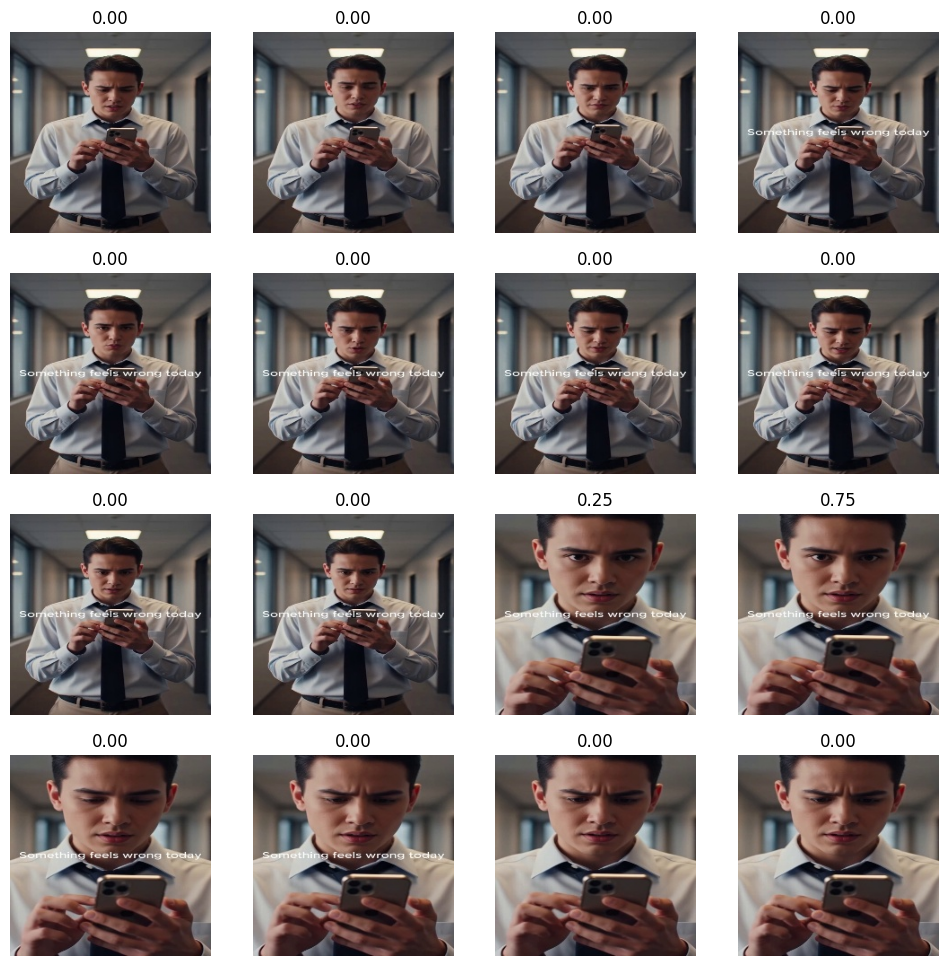


Explanation:
The video is predicted as perception_manipulation because visual and textual cues indicate potential misinformation.


array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.25,
       0.75, 0.  , 0.  , 0.  , 0.  ])

In [18]:
run_xai("TEST_PM_041")


==================== XAI REPORT ====================
Video: TEST_SUS_055
True label: scientifically_unrealistic_scene
Predicted: scientifically_unrealistic_scene (conf=1.0000)

Frame Importance Scores:
Frame 01 → 0.000
Frame 02 → 0.111
Frame 03 → 0.111
Frame 04 → 0.000
Frame 05 → 0.000
Frame 06 → 0.000
Frame 07 → 0.111
Frame 08 → 0.111
Frame 09 → 0.000
Frame 10 → 0.111
Frame 11 → 0.111
Frame 12 → 0.000
Frame 13 → 0.000
Frame 14 → 0.111
Frame 15 → 0.111
Frame 16 → 0.111


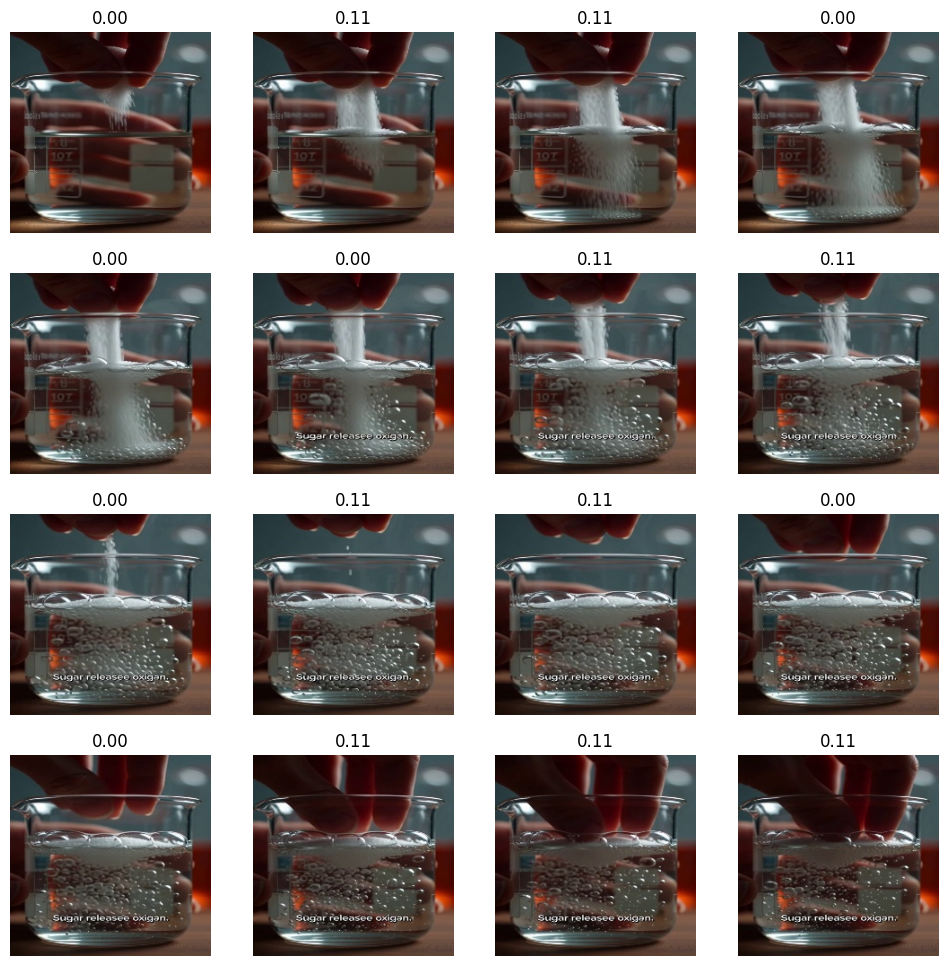


Explanation:
The video is predicted as scientifically_unrealistic_scene because visual and textual cues indicate potential misinformation.


array([0.        , 0.11111111, 0.11111111, 0.        , 0.        ,
       0.        , 0.11111111, 0.11111111, 0.        , 0.11111111,
       0.11111111, 0.        , 0.        , 0.11111111, 0.11111111,
       0.11111111])

In [19]:
run_xai("TEST_SUS_055")


==================== XAI REPORT ====================
Video: TEST_IF_079
True label: identity_fabrication
Predicted: identity_fabrication (conf=0.9988)

Frame Importance Scores:
Frame 01 → 0.003
Frame 02 → 0.053
Frame 03 → 0.071
Frame 04 → 0.116
Frame 05 → 0.089
Frame 06 → 0.058
Frame 07 → 0.062
Frame 08 → 0.079
Frame 09 → 0.123
Frame 10 → 0.080
Frame 11 → 0.039
Frame 12 → 0.037
Frame 13 → 0.046
Frame 14 → 0.044
Frame 15 → 0.056
Frame 16 → 0.043


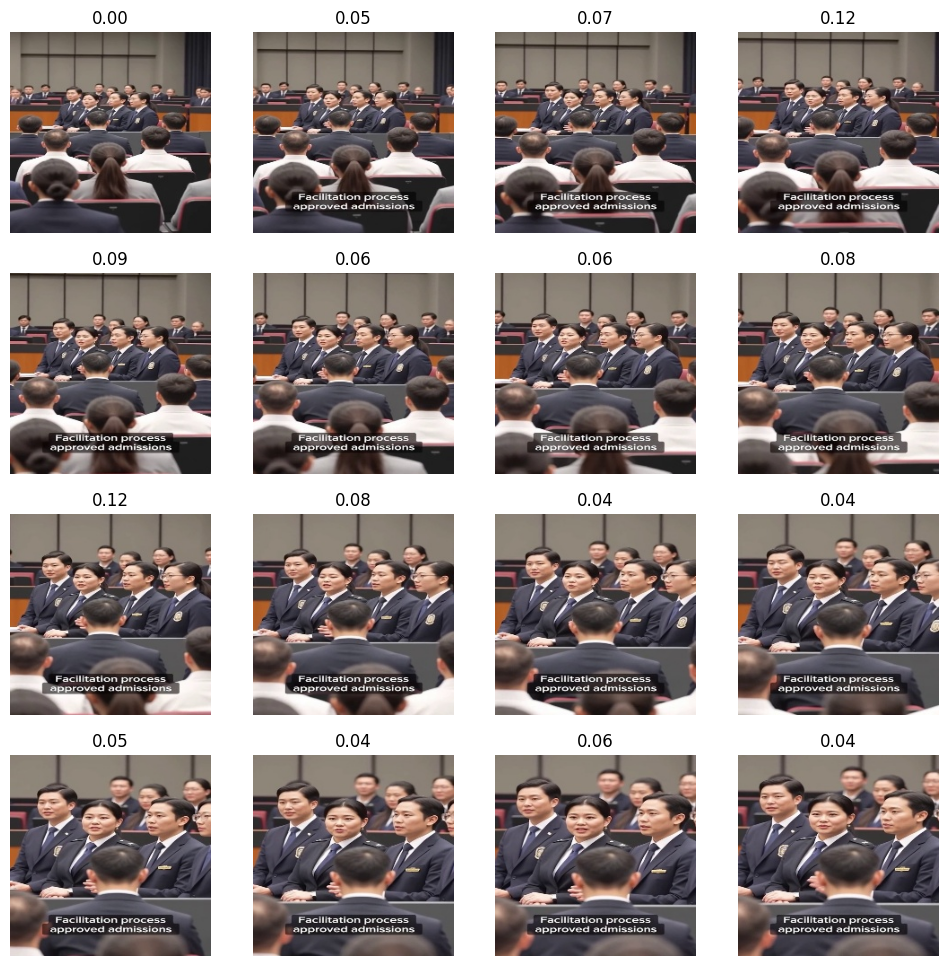


Explanation:
The video is predicted as identity_fabrication because visual and textual cues indicate potential misinformation.


array([0.00310277, 0.0528423 , 0.07128127, 0.11624926, 0.08949816,
       0.05820395, 0.06198565, 0.07876219, 0.12272765, 0.08001853,
       0.03869899, 0.03709367, 0.04635757, 0.04435886, 0.0555263 ,
       0.04329287])

In [20]:
run_xai("TEST_IF_079")


==================== XAI REPORT ====================
Video: TEST_SC_099
True label: surreal_content
Predicted: surreal_content (conf=0.8952)

Frame Importance Scores:
Frame 01 → 0.092
Frame 02 → 0.081
Frame 03 → 0.073
Frame 04 → 0.071
Frame 05 → 0.051
Frame 06 → 0.055
Frame 07 → 0.057
Frame 08 → 0.065
Frame 09 → 0.069
Frame 10 → 0.044
Frame 11 → 0.053
Frame 12 → 0.060
Frame 13 → 0.061
Frame 14 → 0.057
Frame 15 → 0.051
Frame 16 → 0.060


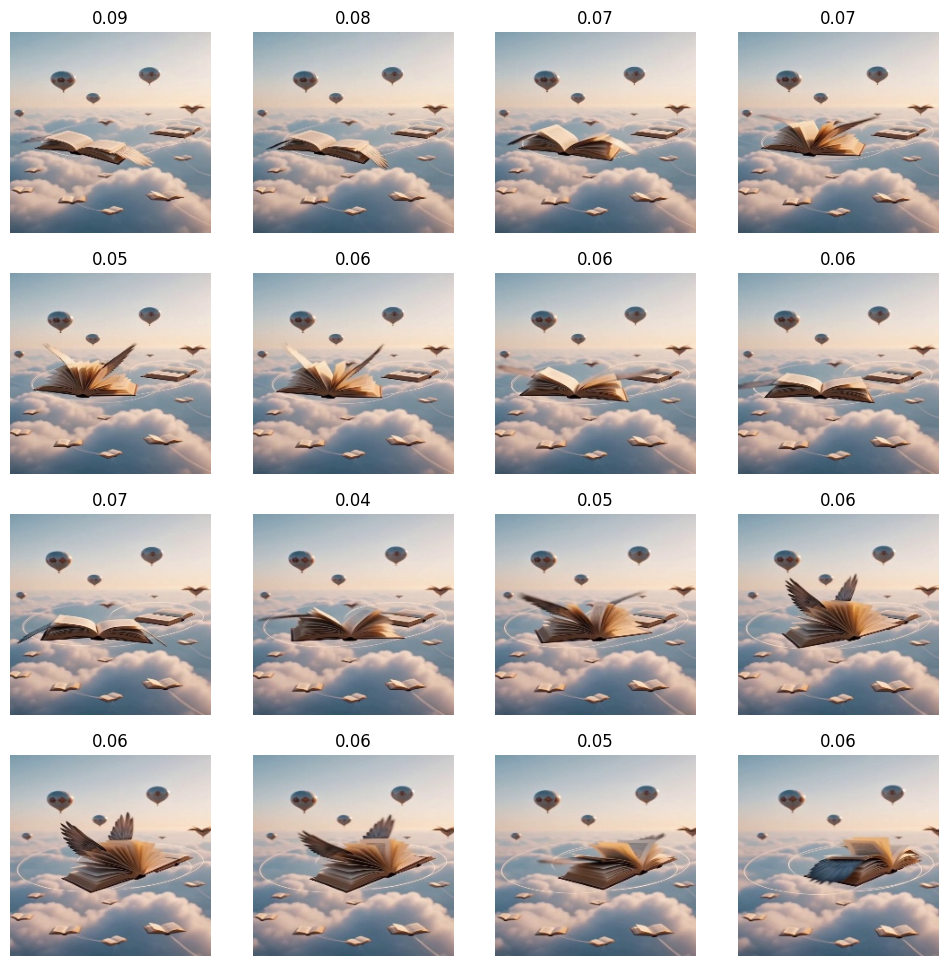


Explanation:
The video is predicted as surreal_content because visual and textual cues indicate potential misinformation.


array([0.09238407, 0.08099568, 0.07258321, 0.07117402, 0.05097608,
       0.05530904, 0.05683789, 0.06488202, 0.06886389, 0.04440338,
       0.05250431, 0.06036699, 0.06106085, 0.05668944, 0.05131425,
       0.05965488])

In [21]:
run_xai("TEST_SC_099")


==================== XAI REPORT ====================
Video: TEST_SAFE_025
True label: safe
Predicted: safe (conf=0.9725)

Frame Importance Scores:
Frame 01 → 0.000
Frame 02 → 0.015
Frame 03 → 0.152
Frame 04 → 0.100
Frame 05 → 0.170
Frame 06 → 0.061
Frame 07 → 0.231
Frame 08 → 0.008
Frame 09 → 0.055
Frame 10 → 0.000
Frame 11 → 0.075
Frame 12 → 0.080
Frame 13 → 0.000
Frame 14 → 0.000
Frame 15 → 0.052
Frame 16 → 0.000


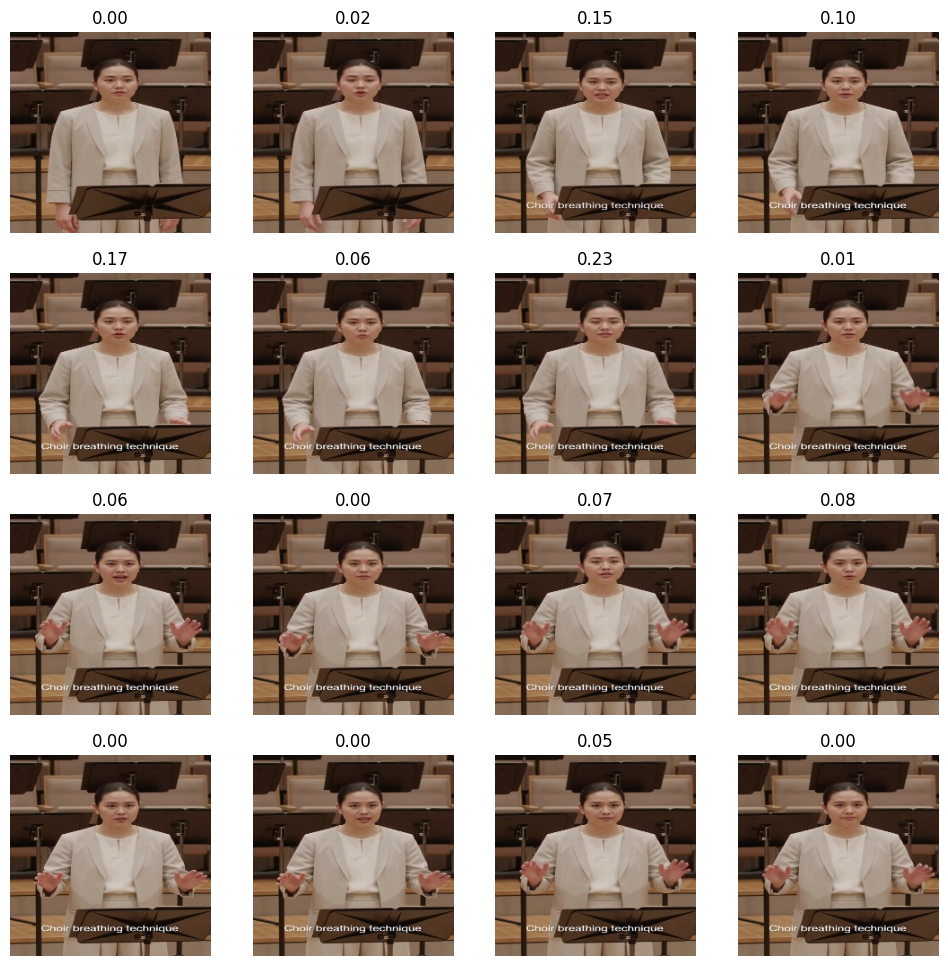


Explanation:
The video appears normal and does not contain misleading cues.


array([0.        , 0.01517207, 0.15243372, 0.10038191, 0.16985273,
       0.06052827, 0.23083318, 0.00764169, 0.05536657, 0.        ,
       0.07492817, 0.08038553, 0.        , 0.        , 0.05247616,
       0.        ])

In [22]:
run_xai("TEST_SAFE_025")